# Volve 6 — reservoir simulation, production history matching, and forecast

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/volve/06_volve_reservoir_history_matching.ipynb)

**Notebook 6 — Volve field-calculation extension**

The authoritative measured-data boundary is Equinor's Volve Data
Village listing in Databricks Marketplace. Normal execution reads
an installed Unity Catalog Volume and never stores credentials or
redistributes the source package.

The retained clean-runtime output uses an explicitly requested,
deterministic teaching fixture. Every such output is marked
**DEMONSTRATION_FALLBACK**. It is not measured Volve production, a
history match, a reserves statement, or a design certification.


## Learning outcomes and engineering decisions

            - obtain measured well production from the Databricks Marketplace Volume
- audit dates, wells, allocation, downtime, volumes, pressure, and units
- derive NeqSim PVT anchors for the dynamic black-oil calculation
- run a communicating two-tank reservoir simulator for every report month
- fit pressure, oil, gas, and water simultaneously with robust least squares
- separate calibration from holdout validation and quantify identifiability
- propagate parameter uncertainty into a constrained field forecast
- export fitted reservoir and per-well deliverability data to the SURF notebook

            The notebook writes a versioned contract so later calculations
            consume named quantities, units, provenance, fitted parameters,
            validity limits, and uncertainty rather than hidden state.


## Data provenance and licence

Primary sources and software:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve open-data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [OPM Flow](https://opm-project.org/?page_id=19)
- [NeqSim](https://github.com/equinor/neqsim)
- [NeqSim Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)

Equinor states that the release contains subsurface, production,
and operating data from the 2008–2016 production period. The
notebook selects only the production workbook and, when requested,
one reservoir deck with its controlled include directory. The book
supplies the lifecycle and production-technology learning spine;
this Volve series applies those topics to one traceable field case.


## Clean-runtime setup and source policy

Normal Colab execution installs the Python bridges, clones current
`equinor/neqsim` master, records the resolved commit, builds the
runtime JAR, and verifies the loaded Java class origin. Local
validation sets `VOLVE_VALIDATION_MODE=1` and uses the pinned
NeqSim 3.17.0 release JAR. The validation runtime proves notebook
logic, but it does not replace the required current-master and
authenticated Marketplace acceptance runs.


In [1]:
from importlib.metadata import version
import hashlib
import json
import math
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    packages = [
        "neqsim==3.17.0",
        "databricks-sdk==0.72.0",
        "openpyxl==3.1.5",
        "xlrd==2.0.2",
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted(
        (source_dir / "target").glob(
            "neqsim-*-jar-with-dependencies.jar"
        )
    )
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = str(protection.getLocation()) if protection else "bundled JAR"
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "NeqSim source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'NeqSim source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import brentq, least_squares

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace inventory and bounded production selection

Set `VOLVE_DATA_MODE=marketplace` and provide either:

1. `VOLVE_VOLUME_ROOT` for a mounted or exported Volume; or
2. `VOLVE_REMOTE_VOLUME_ROOT` plus `DATABRICKS_HOST` and
   `DATABRICKS_TOKEN` in Colab Secrets.

`VOLVE_PRODUCTION_PATH` identifies the production workbook. Remote
execution downloads only that selected file. The token is never
printed, written to a contract, or retained in notebook output.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

production_candidates = inventory.loc[
    inventory["domain"].eq("production-history"),
    ["relative_path", "bytes"],
].copy()
display(production_candidates.head(20))

if source.measured_data_loaded:
    production_relative_path = vc.select_asset(
        inventory,
        "production-history",
        environment_name="VOLVE_PRODUCTION_PATH",
    )
    production_path = vc.materialize_asset(
        source,
        inventory,
        production_relative_path,
        work_dir / "marketplace_inputs",
    )
    production = vc.read_production_history(production_path)
    production_provenance = dict(production.attrs)
else:
    production_relative_path = "DEMONSTRATION_FALLBACK"
    production = vc.demo_production_history()
    production_provenance = {
        "source_path": "deterministic teaching fixture",
        "source_sha256": None,
        "sheet_name": None,
        "raw_rows": len(production),
        "normalized_rows": len(production),
    }

display(pd.DataFrame([production_provenance]))
display(production.head())
print(
    {
        "wells": sorted(production["well"].unique()),
        "rows": len(production),
        "data status": production["data_status"].unique().tolist(),
    }
)


{'wells': ['15/9-F-1 C', '15/9-F-11 B', '15/9-F-12', '15/9-F-14', '15/9-F-15 D'], 'rows': 520, 'data status': ['DEMONSTRATION_FALLBACK']}


,relative_path,bytes
6,Production/volve_daily_production.xlsx,2400000


,source_path,source_sha256,sheet_name,raw_rows,normalized_rows
0,deterministic teaching fixture,None,None,520,520


,date,well,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,on_stream_fraction,data_status
0,2008-02-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
1,2008-03-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
2,2008-04-01,15/9-F-1 C,0.000000,0.000000,0.000000,0.000000,DEMONSTRATION_FALLBACK
3,2008-05-01,15/9-F-1 C,199.020090,23896.122612,18.971926,0.199020,DEMONSTRATION_FALLBACK
4,2008-06-01,15/9-F-1 C,402.739247,48360.148968,38.745789,0.402739,DEMONSTRATION_FALLBACK


## 1. Production-history quality control

The Marketplace workbook is normalized to one monthly row per well.
Source columns such as `DATEPRD`, `NPD_WELL_BORE_NAME`,
`BORE_OIL_VOL`, `BORE_GAS_VOL`, `BORE_WAT_VOL`, and
`ON_STREAM_HRS` are mapped conservatively. Volumes are aggregated
by calendar month and divided by the number of days in that month.

Negative corrections, missing dates, duplicated well-months,
implausible uptime, and non-finite rates are reported before any
model is fitted. Corrections are not silently discarded.


In [4]:
rate_columns = [
    "oil_rate_Sm3_day",
    "gas_rate_Sm3_day",
    "water_rate_Sm3_day",
]
duplicate_count = int(
    production.duplicated(subset=["date", "well"]).sum()
)
negative_rate_count = int(
    production[rate_columns].lt(0.0).sum().sum()
)
nonfinite_rate_count = int(
    (~np.isfinite(production[rate_columns].to_numpy())).sum()
)
history_qc = pd.DataFrame(
    {
        "check": [
            "duplicate well-month rows",
            "negative phase-rate values",
            "non-finite phase-rate values",
            "production start",
            "production end",
            "unique wells",
        ],
        "value": [
            duplicate_count,
            negative_rate_count,
            nonfinite_rate_count,
            production["date"].min(),
            production["date"].max(),
            production["well"].nunique(),
        ],
    }
)
display(history_qc)

if duplicate_count or nonfinite_rate_count:
    raise RuntimeError("Production-history identity or finiteness failed.")
if negative_rate_count:
    raise RuntimeError(
        "Review negative production corrections before fitting."
    )


,check,value
0,duplicate well-month rows,0
1,negative phase-rate values,0
2,non-finite phase-rate values,0
3,production start,2008-02-01 00:00:00
4,production end,2016-09-01 00:00:00
5,unique wells,5


In [5]:
field_history = vc.field_monthly_history(production)
well_month = production.copy()
well_month["active"] = well_month[rate_columns].sum(axis=1).gt(1.0)
operations = (
    well_month.groupby("date", as_index=False)
    .agg(
        active_wells=("active", "sum"),
        mean_on_stream=("on_stream_fraction", "mean"),
    )
    .sort_values("date")
)
field_history = field_history.merge(operations, on="date", how="left")
operating_index = (
    field_history["active_wells"]
    * field_history["mean_on_stream"].fillna(1.0)
)
field_history["operating_index"] = (
    operating_index / max(float(operating_index.max()), 1.0)
)

if "downhole_pressure_bara" in production.columns:
    pressure_observations = (
        production.groupby("date", as_index=False)[
            "downhole_pressure_bara"
        ]
        .mean()
        .rename(columns={"downhole_pressure_bara": "pressure_bara"})
    )
    field_history = field_history.merge(
        pressure_observations,
        on="date",
        how="left",
    )
else:
    field_history["pressure_bara"] = np.nan

if not field_history["pressure_bara"].notna().any():
    pressure_screen = vc.reservoir_screen(production)
    field_history["pressure_bara"] = pressure_screen[
        "average_pressure_bara"
    ].to_numpy()
    pressure_basis = "DEMONSTRATION_FALLBACK material-balance screen"
else:
    field_history["pressure_bara"] = field_history[
        "pressure_bara"
    ].interpolate(limit_direction="both")
    pressure_basis = "MEASURED_VOLVE downhole-pressure monthly mean"

field_history["elapsed_days"] = (
    field_history["date"] - field_history["date"].min()
).dt.days.astype(float)
display(field_history.head())
print({"pressure basis": pressure_basis})


{'pressure basis': 'DEMONSTRATION_FALLBACK material-balance screen'}


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,liquid_rate_Sm3_day,water_cut_fraction,gor_Sm3_Sm3,active_wells,mean_on_stream,operating_index,pressure_bara,elapsed_days
0,2008-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,265.000000,0.0
1,2008-03-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,265.000000,29.0
2,2008-04-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,265.000000,60.0
3,2008-05-01,199.020090,23896.122612,18.971926,217.992016,0.087030,120.068897,1,0.039804,0.011791,264.938128,90.0
4,2008-06-01,402.739247,48360.148968,38.745789,441.485036,0.087762,120.078064,1,0.080548,0.023860,264.812939,121.0


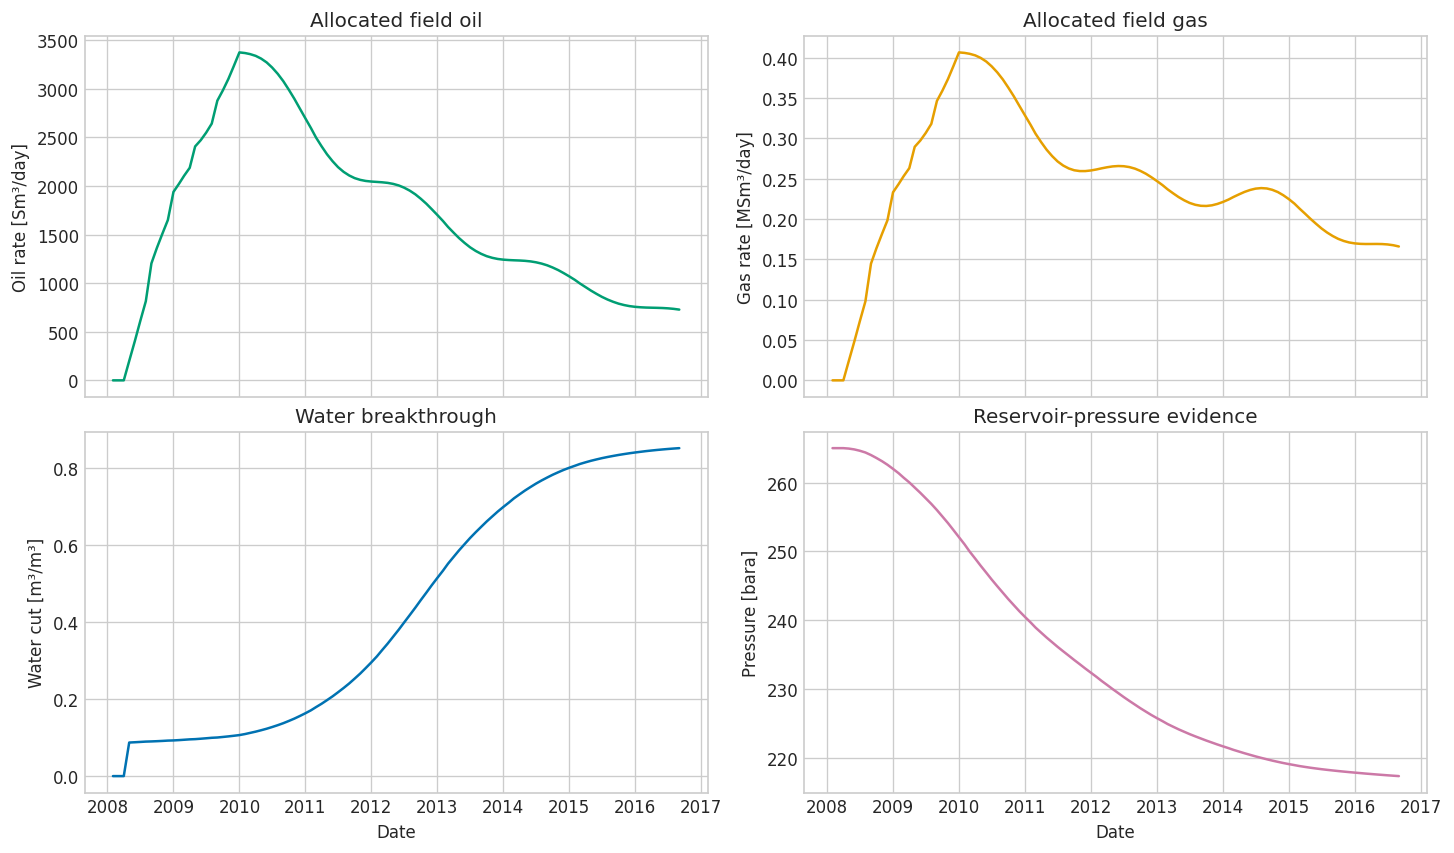

In [6]:
history_figure, history_axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.0),
    sharex=True,
    constrained_layout=True,
)
history_axes[0, 0].plot(
    field_history["date"],
    field_history["oil_rate_Sm3_day"],
    color="#009E73",
)
history_axes[0, 0].set(
    ylabel="Oil rate [Sm³/day]",
    title="Allocated field oil",
)
history_axes[0, 1].plot(
    field_history["date"],
    field_history["gas_rate_Sm3_day"] / 1.0e6,
    color="#E69F00",
)
history_axes[0, 1].set(
    ylabel="Gas rate [MSm³/day]",
    title="Allocated field gas",
)
history_axes[1, 0].plot(
    field_history["date"],
    field_history["water_cut_fraction"],
    color="#0072B2",
)
history_axes[1, 0].set(
    ylabel="Water cut [m³/m³]",
    title="Water breakthrough",
)
history_axes[1, 1].plot(
    field_history["date"],
    field_history["pressure_bara"],
    color="#CC79A7",
)
history_axes[1, 1].set(
    ylabel="Pressure [bara]",
    title="Reservoir-pressure evidence",
)
for axis in history_axes[-1, :]:
    axis.set_xlabel("Date")
plt.show()


## 2. NeqSim PVT anchors

The dynamic simulator uses black-oil source properties derived from
a compositional SRK fluid. The saved assay is a teaching fluid. A
measured run must replace its composition, plus-fraction molecular
weight and density, recombination basis, and laboratory conditions
with the selected Volve PVT evidence.

The material-balance conversion uses oil formation-volume factor
$B_o$, water formation-volume factor $B_w$, gas formation-volume
factor $B_g$, solution GOR $R_s$, and bubble pressure $p_b$.
Pressure is absolute and rates are standard volumes per day.


In [7]:
reservoir_temperature_c = 97.5
initial_pressure_bara = 260.0
fluid = jneqsim.thermo.system.SystemSrkEos(
    reservoir_temperature_c + 273.15,
    initial_pressure_bara,
)
assay = [
    ("nitrogen", 0.004),
    ("CO2", 0.003),
    ("methane", 0.402),
    ("ethane", 0.076),
    ("propane", 0.080),
    ("i-butane", 0.012),
    ("n-butane", 0.041),
    ("i-pentane", 0.014),
    ("n-pentane", 0.022),
    ("n-hexane", 0.028),
]
for component_name, mole_fraction in assay:
    fluid.addComponent(component_name, mole_fraction)
fluid.addTBPfraction("C7", 0.160, 0.115, 0.75)
fluid.addTBPfraction("C10", 0.158, 0.260, 0.88)
fluid.setMixingRule("classic")
fluid.useVolumeCorrection(True)
fluid.setMultiPhaseCheck(True)
fluid.init(0)

saturation = jneqsim.pvtsimulation.simulation.SaturationPressure(
    fluid.clone()
)
saturation.setTemperature(reservoir_temperature_c, "C")
saturation.run()
bubble_pressure_bara = float(saturation.getSaturationPressure())

pvt_rows = []
for pressure_bara in [260.0, 220.0, 180.0, 140.0, 100.0]:
    state = fluid.clone()
    state.setPressure(pressure_bara, "bara")
    state.setTemperature(reservoir_temperature_c, "C")
    TPflash(state)
    state.initPhysicalProperties()
    oil_density = np.nan
    gas_density = np.nan
    if state.hasPhaseType("oil"):
        oil_density = state.getPhase("oil").getDensity("kg/m3")
    if state.hasPhaseType("gas"):
        gas_density = state.getPhase("gas").getDensity("kg/m3")
    pvt_rows.append(
        {
            "pressure_bara": pressure_bara,
            "oil_density_kg_m3": oil_density,
            "gas_density_kg_m3": gas_density,
            "phase_count": state.getNumberOfPhases(),
        }
    )
pvt_anchor = pd.DataFrame(pvt_rows)
composition_sum = sum(value for _, value in assay) + 0.318
display(pvt_anchor)
print(
    {
        "EOS": "SRK",
        "mixing rule": "classic",
        "composition sum": composition_sum,
        "bubble pressure bara": bubble_pressure_bara,
    }
)


{'EOS': 'SRK', 'mixing rule': 'classic', 'composition sum': 1.0, 'bubble pressure bara': 178.84027099609375}


,pressure_bara,oil_density_kg_m3,gas_density_kg_m3,phase_count
0,260.0,638.277191,NaN,1
1,220.0,629.081068,NaN,1
2,180.0,618.680565,NaN,1
3,140.0,644.904915,114.403835,2
4,100.0,672.683698,80.433593,2


## 3. Communicating two-tank reservoir simulator

The executable fallback is a reduced finite-volume reservoir model,
not a decline-curve fit. Two tanks exchange fluids and pressure.
Each monthly step calculates pressure-dependent well potential,
depletion, aquifer support, water breakthrough, and liberated gas.

For tank $i$, the oil potential and pressure target are

$$q_{o,i}=J_i A(t)(p_i-p_{wf})\exp(-dN_{p,i}/N_i)$$

$$p_i^*=p_{i,0}-C_d\frac{N_{p,i}}{N_i}+C_a\left(1-e^{-t/\tau_a}\right)$$

and pressure communication is applied as

$$p_i(t+\Delta t)=p_i^*+T_{12}\left(p_j-p_i\right)\Delta t$$

where $J_i$ is productivity, $A(t)$ is the observed operating
index, $C_d$ is depletion strength, $C_a$ is aquifer support, and
$T_{12}$ is inter-tank communication. Water cut follows a bounded
sigmoid in recovery; GOR rises below the NeqSim bubble pressure.


In [8]:
PARAMETER_NAMES = [
    "oil_in_place_MSm3",
    "productivity_Sm3_day_bar",
    "depletion_bar_per_recovery",
    "aquifer_support_bar",
    "communication_fraction_month",
    "tank_one_fraction",
    "water_breakthrough_recovery",
    "water_transition_width",
    "base_gor_Sm3_Sm3",
    "liberated_gor_per_bar",
    "depletion_deliverability_multiplier",
]
LOWER_BOUNDS = np.array(
    [8.0, 8.0, 70.0, 0.0, 0.0, 0.30, 0.03, 0.02, 70.0, 0.1, 0.2]
)
UPPER_BOUNDS = np.array(
    [40.0, 70.0, 260.0, 90.0, 0.35, 0.75, 0.70, 0.30, 240.0, 4.0, 10.0]
)
INITIAL_PARAMETERS = np.array(
    [15.0, 28.0, 155.0, 22.0, 0.08, 0.55, 0.28, 0.10, 120.0, 1.1, 2.0]
)


def simulate_two_tank(parameters, history):
    (
        oil_in_place_msm3,
        productivity,
        depletion_strength,
        aquifer_support,
        communication,
        tank_one_fraction,
        water_breakthrough,
        water_width,
        base_gor,
        liberated_gor_slope,
        deliverability_decline,
    ) = parameters
    oil_in_place_sm3 = oil_in_place_msm3 * 1.0e6
    tank_oil = np.array(
        [tank_one_fraction, 1.0 - tank_one_fraction]
    ) * oil_in_place_sm3
    tank_productivity = np.array([1.12, 0.88]) * productivity
    tank_breakthrough = water_breakthrough * np.array([0.82, 1.18])
    tank_pressure = np.array([initial_pressure_bara, initial_pressure_bara])
    cumulative_oil = np.zeros(2)
    elapsed_months = np.arange(len(history), dtype=float)
    records = []
    for row_index, (_, history_row) in enumerate(history.iterrows()):
        recovery = cumulative_oil / tank_oil
        operating_index = float(history_row["operating_index"])
        drawdown = np.maximum(tank_pressure - 78.0, 0.0)
        decline = np.exp(-deliverability_decline * recovery)
        oil_rate_tank = (
            tank_productivity * operating_index * drawdown * decline
        )
        water_cut_tank = 0.04 + 0.91 / (
            1.0
            + np.exp(
                -(recovery - tank_breakthrough)
                / max(water_width, 1.0e-6)
            )
        )
        water_rate_tank = oil_rate_tank * water_cut_tank / np.maximum(
            1.0 - water_cut_tank,
            0.03,
        )
        gor_tank = base_gor + liberated_gor_slope * np.maximum(
            bubble_pressure_bara - tank_pressure,
            0.0,
        )
        gas_rate_tank = oil_rate_tank * gor_tank
        month_days = float(history_row["date"].days_in_month)
        cumulative_oil += oil_rate_tank * month_days
        updated_recovery = cumulative_oil / tank_oil
        time_fraction = elapsed_months[row_index] / max(len(history) - 1, 1)
        pressure_target = (
            initial_pressure_bara
            - depletion_strength * updated_recovery
            + aquifer_support * (1.0 - np.exp(-3.0 * time_fraction))
        )
        pressure_difference = tank_pressure[::-1] - tank_pressure
        tank_pressure = pressure_target + communication * pressure_difference
        tank_pressure = np.clip(tank_pressure, 70.0, initial_pressure_bara)
        field_oil_rate = float(oil_rate_tank.sum())
        field_water_rate = float(water_rate_tank.sum())
        field_gas_rate = float(gas_rate_tank.sum())
        records.append(
            {
                "date": history_row["date"],
                "oil_rate_Sm3_day": field_oil_rate,
                "gas_rate_Sm3_day": field_gas_rate,
                "water_rate_Sm3_day": field_water_rate,
                "water_cut_fraction": field_water_rate
                / max(field_oil_rate + field_water_rate, 1.0e-12),
                "gor_Sm3_Sm3": field_gas_rate
                / max(field_oil_rate, 1.0e-12),
                "pressure_bara": float(np.average(tank_pressure)),
                "tank_one_pressure_bara": float(tank_pressure[0]),
                "tank_two_pressure_bara": float(tank_pressure[1]),
                "cumulative_oil_MSm3": float(cumulative_oil.sum() / 1.0e6),
            }
        )
    return pd.DataFrame(records)


prior_simulation = simulate_two_tank(
    INITIAL_PARAMETERS,
    field_history,
)
display(prior_simulation.head())


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,water_cut_fraction,gor_Sm3_Sm3,pressure_bara,tank_one_pressure_bara,tank_two_pressure_bara,cumulative_oil_MSm3
0,2008-02-01,0.000000,0.000000,0.000000,0.000000,0.0,260.0,260.0,260.0,0.000000
1,2008-03-01,0.000000,0.000000,0.000000,0.000000,0.0,260.0,260.0,260.0,0.000000
2,2008-04-01,0.000000,0.000000,0.000000,0.000000,0.0,260.0,260.0,260.0,0.000000
3,2008-05-01,120.170217,14420.426013,13.575235,0.101501,120.0,260.0,260.0,260.0,0.003725
4,2008-06-01,243.056969,29166.836274,27.500564,0.101644,120.0,260.0,260.0,260.0,0.011017


## 4. Multi-objective history-match residuals

Oil rate, water cut, GOR, and pressure use different scales. The
objective therefore fits dimensionless residuals with robust
`soft_l1` loss. Log-rate residuals emphasize relative error without
allowing high-rate months to dominate. The final 25% of report
months is held out and is never used by the optimizer.

$$r_o=\frac{\ln(1+q_o^{sim})-\ln(1+q_o^{obs})}{\sigma_{\ln q_o}}$$

Analogous residuals use engineering tolerances for water cut, GOR,
and pressure. These weights express calibration priorities; they
are not measurement-error estimates unless independently justified.


In [9]:
calibration_count = max(int(0.75 * len(field_history)), 24)
calibration_history = field_history.iloc[:calibration_count].copy()
validation_history = field_history.iloc[calibration_count:].copy()


def residual_vector(parameters, observed_history):
    simulated = simulate_two_tank(parameters, observed_history)
    oil_residual = (
        np.log1p(simulated["oil_rate_Sm3_day"].to_numpy())
        - np.log1p(observed_history["oil_rate_Sm3_day"].to_numpy())
    ) / 0.20
    water_cut_residual = (
        simulated["water_cut_fraction"].to_numpy()
        - observed_history["water_cut_fraction"].to_numpy()
    ) / 0.08
    observed_gor = observed_history["gor_Sm3_Sm3"].to_numpy()
    gor_residual = (
        simulated["gor_Sm3_Sm3"].to_numpy() - observed_gor
    ) / 30.0
    pressure_residual = (
        simulated["pressure_bara"].to_numpy()
        - observed_history["pressure_bara"].to_numpy()
    ) / 10.0
    return np.concatenate(
        [
            oil_residual,
            water_cut_residual,
            gor_residual,
            pressure_residual,
        ]
    )


prior_residual = residual_vector(
    INITIAL_PARAMETERS,
    calibration_history,
)
history_match = least_squares(
    residual_vector,
    INITIAL_PARAMETERS,
    bounds=(LOWER_BOUNDS, UPPER_BOUNDS),
    args=(calibration_history,),
    loss="soft_l1",
    f_scale=1.0,
    x_scale="jac",
    max_nfev=500,
    verbose=0,
)
fitted_parameters = history_match.x
posterior_residual = residual_vector(
    fitted_parameters,
    calibration_history,
)
parameter_table = pd.DataFrame(
    {
        "parameter": PARAMETER_NAMES,
        "lower": LOWER_BOUNDS,
        "prior": INITIAL_PARAMETERS,
        "fitted": fitted_parameters,
        "upper": UPPER_BOUNDS,
    }
)
display(parameter_table)
print(
    {
        "optimizer success": history_match.success,
        "function evaluations": history_match.nfev,
        "prior RMS": float(np.sqrt(np.mean(prior_residual**2))),
        "posterior RMS": float(
            np.sqrt(np.mean(posterior_residual**2))
        ),
    }
)


{'optimizer success': True, 'function evaluations': 33, 'prior RMS': 1.9578025261044545, 'posterior RMS': 0.9549553060285819}


,parameter,lower,prior,fitted,upper
0,oil_in_place_MSm3,8.00,15.00,15.842151,40.00
1,productivity_Sm3_day_bar,8.00,28.00,12.597283,70.00
2,depletion_bar_per_recovery,70.00,155.00,117.888220,260.00
3,aquifer_support_bar,0.00,22.00,2.879395,90.00
4,communication_fraction_month,0.00,0.08,0.350000,0.35
5,tank_one_fraction,0.30,0.55,0.728701,0.75
6,water_breakthrough_recovery,0.03,0.28,0.299253,0.70
7,water_transition_width,0.02,0.10,0.057239,0.30
8,base_gor_Sm3_Sm3,70.00,120.00,131.920199,240.00
9,liberated_gor_per_bar,0.10,1.10,0.104574,4.00


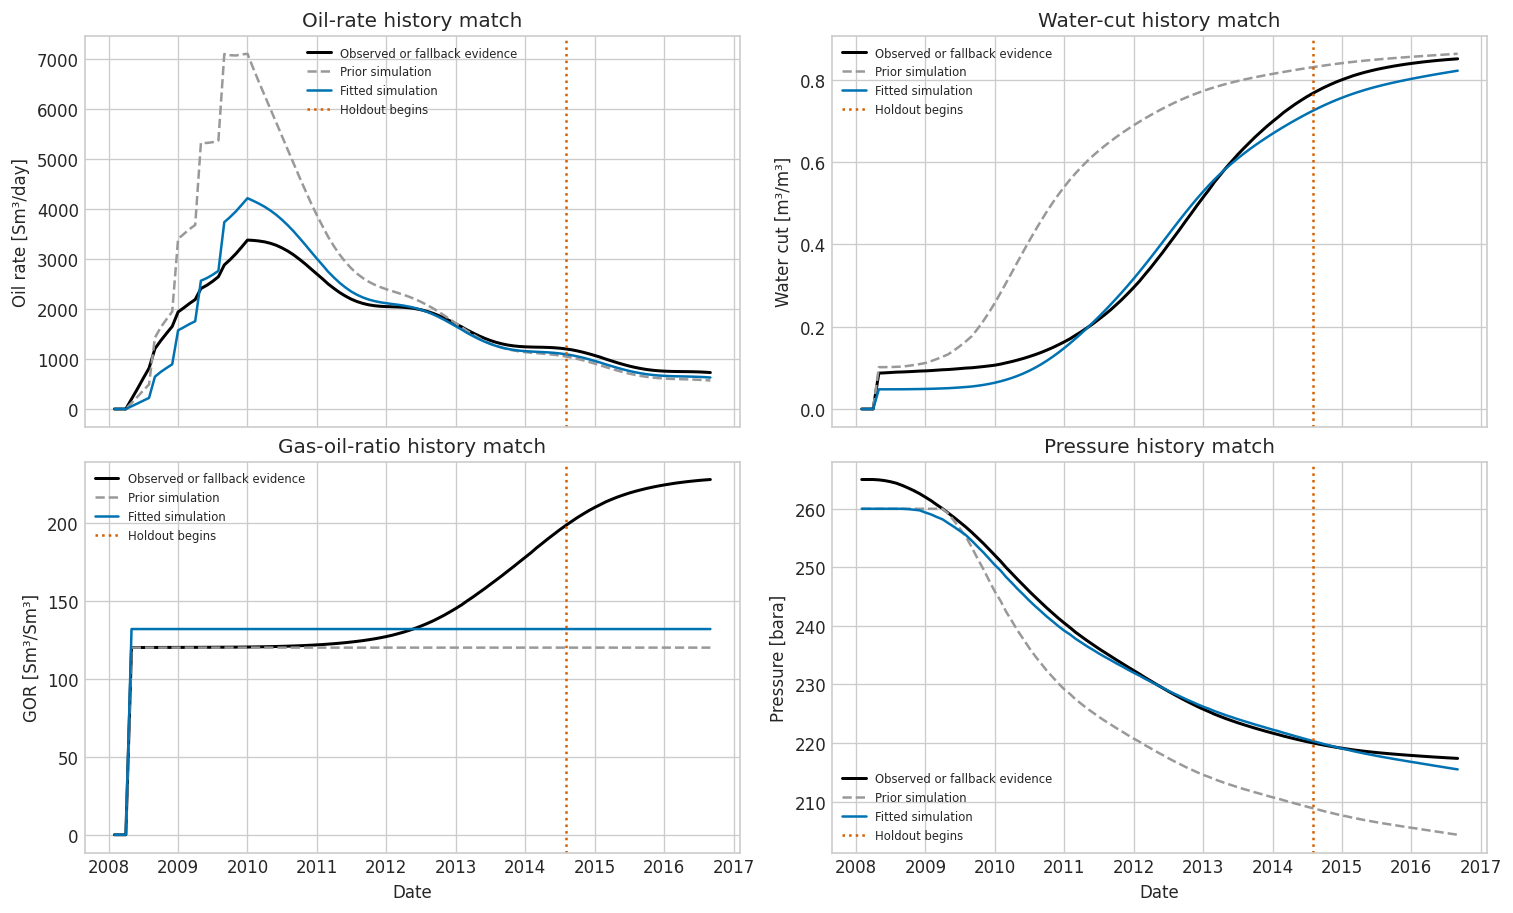

In [10]:
matched_history = simulate_two_tank(
    fitted_parameters,
    field_history,
)

match_figure, match_axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 7.5),
    sharex=True,
    constrained_layout=True,
)
comparisons = [
    (
        "oil_rate_Sm3_day",
        "Oil rate [Sm³/day]",
        "Oil-rate history match",
    ),
    (
        "water_cut_fraction",
        "Water cut [m³/m³]",
        "Water-cut history match",
    ),
    (
        "gor_Sm3_Sm3",
        "GOR [Sm³/Sm³]",
        "Gas-oil-ratio history match",
    ),
    (
        "pressure_bara",
        "Pressure [bara]",
        "Pressure history match",
    ),
]
for axis, (column, ylabel, title) in zip(
    match_axes.ravel(),
    comparisons,
):
    axis.plot(
        field_history["date"],
        field_history[column],
        color="black",
        linewidth=1.8,
        label="Observed or fallback evidence",
    )
    axis.plot(
        prior_simulation["date"],
        prior_simulation[column],
        color="#999999",
        linestyle="--",
        label="Prior simulation",
    )
    axis.plot(
        matched_history["date"],
        matched_history[column],
        color="#0072B2",
        label="Fitted simulation",
    )
    axis.axvline(
        validation_history["date"].min(),
        color="#D55E00",
        linestyle=":",
        label="Holdout begins",
    )
    axis.set(ylabel=ylabel, title=title)
    axis.legend(fontsize=7)
for axis in match_axes[-1, :]:
    axis.set_xlabel("Date")
plt.show()


In [11]:
def model_metrics(observed, simulated):
    oil_error = (
        simulated["oil_rate_Sm3_day"].to_numpy()
        - observed["oil_rate_Sm3_day"].to_numpy()
    )
    water_cut_error = (
        simulated["water_cut_fraction"].to_numpy()
        - observed["water_cut_fraction"].to_numpy()
    )
    pressure_error = (
        simulated["pressure_bara"].to_numpy()
        - observed["pressure_bara"].to_numpy()
    )
    return {
        "oil NRMSE fraction": float(
            np.sqrt(np.mean(oil_error**2))
            / max(observed["oil_rate_Sm3_day"].max(), 1.0)
        ),
        "water-cut RMSE fraction": float(
            np.sqrt(np.mean(water_cut_error**2))
        ),
        "pressure RMSE bar": float(
            np.sqrt(np.mean(pressure_error**2))
        ),
    }


calibration_simulation = matched_history.iloc[:calibration_count]
validation_simulation = matched_history.iloc[calibration_count:]
calibration_metrics = model_metrics(
    calibration_history,
    calibration_simulation,
)
validation_metrics = model_metrics(
    validation_history,
    validation_simulation,
)
metric_table = pd.DataFrame(
    [
        {"period": "calibration", **calibration_metrics},
        {"period": "holdout", **validation_metrics},
    ]
)
display(metric_table)


,period,oil NRMSE fraction,water-cut RMSE fraction,pressure RMSE bar
0,calibration,0.111247,0.030388,1.945327
1,holdout,0.083956,0.039409,0.977023


## 5. Parameter identifiability and alternative simulations

A good visual fit does not prove a unique reservoir description.
The Jacobian singular values expose weak parameter combinations.
Three controlled simulations then isolate aquifer and communication
effects on pressure, water cut, and recovery while holding the
operating history fixed.


{'Jacobian condition number': 328907392551075.8}


,singular value index,singular value
0,1,3.289074e+02
1,2,2.346785e+02
2,3,3.279206e+01
3,4,8.079214e+00
4,5,9.966551e-01
5,6,2.456394e-01
6,7,1.632468e-01
7,8,1.454871e-01
8,9,8.094830e-02
9,10,2.698932e-08


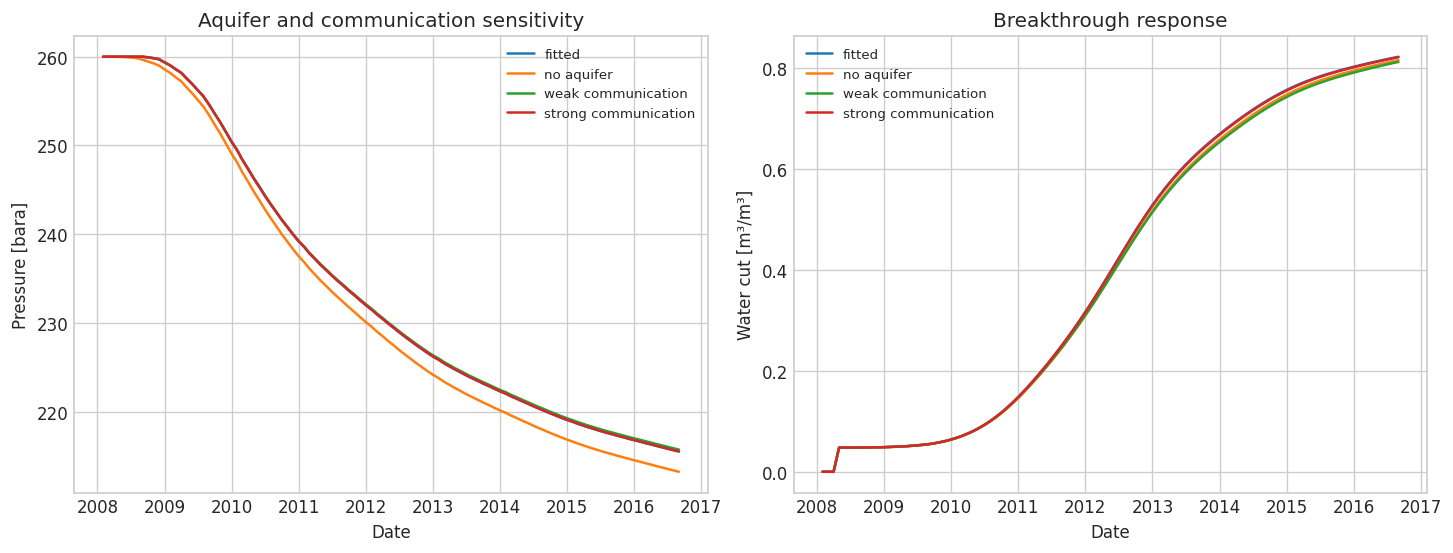

In [12]:
singular_values = np.linalg.svd(
    history_match.jac,
    compute_uv=False,
)
effective_condition_number = float(
    singular_values.max() / max(singular_values.min(), 1.0e-12)
)
identifiability = pd.DataFrame(
    {
        "singular value index": np.arange(1, len(singular_values) + 1),
        "singular value": singular_values,
    }
)
display(identifiability)
print({"Jacobian condition number": effective_condition_number})

alternative_parameters = {
    "fitted": fitted_parameters.copy(),
    "no aquifer": fitted_parameters.copy(),
    "weak communication": fitted_parameters.copy(),
    "strong communication": fitted_parameters.copy(),
}
alternative_parameters["no aquifer"][3] = 0.0
alternative_parameters["weak communication"][4] = 0.0
alternative_parameters["strong communication"][4] = min(
    0.30,
    fitted_parameters[4] * 2.0 + 0.02,
)
alternative_simulations = {
    name: simulate_two_tank(parameters, field_history)
    for name, parameters in alternative_parameters.items()
}

alternative_figure, alternative_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.5),
    constrained_layout=True,
)
for name, simulation in alternative_simulations.items():
    alternative_axes[0].plot(
        simulation["date"],
        simulation["pressure_bara"],
        label=name,
    )
    alternative_axes[1].plot(
        simulation["date"],
        simulation["water_cut_fraction"],
        label=name,
    )
alternative_axes[0].set(
    xlabel="Date",
    ylabel="Pressure [bara]",
    title="Aquifer and communication sensitivity",
)
alternative_axes[1].set(
    xlabel="Date",
    ylabel="Water cut [m³/m³]",
    title="Breakthrough response",
)
for axis in alternative_axes:
    axis.legend(fontsize=8)
plt.show()


## 6. Uncertainty ensemble and forecast

The local covariance approximation uses the fitted Jacobian only
as a proposal distribution. Samples are clipped to engineering
bounds, re-simulated, and summarized as P10, P50, and P90 rate
envelopes. These are model-parameter sensitivities, not reserves
probabilities.

The forward operating index declines from the final observed
availability. Facility and gathering constraints remain outside the
reservoir model and are applied in Notebook 7.


In [13]:
forecast_dates = pd.date_range(
    field_history["date"].max() + pd.offsets.MonthBegin(1),
    periods=60,
    freq="MS",
)
forecast_operations = pd.DataFrame(
    {
        "date": forecast_dates,
        "operating_index": np.clip(
            field_history["operating_index"].iloc[-1]
            * np.exp(-0.008 * np.arange(len(forecast_dates))),
            0.20,
            1.0,
        ),
    }
)
forecast_template = pd.concat(
    [
        field_history,
        forecast_operations.assign(
            oil_rate_Sm3_day=0.0,
            gas_rate_Sm3_day=0.0,
            water_rate_Sm3_day=0.0,
            water_cut_fraction=0.0,
            gor_Sm3_Sm3=0.0,
            pressure_bara=np.nan,
        ),
    ],
    ignore_index=True,
)

residual_degrees = max(
    len(posterior_residual) - len(fitted_parameters),
    1,
)
residual_variance = float(
    np.sum(posterior_residual**2) / residual_degrees
)
information_matrix = history_match.jac.T @ history_match.jac
parameter_covariance = (
    np.linalg.pinv(information_matrix) * residual_variance
)
random = np.random.default_rng(20260815)
ensemble_size = 120
raw_samples = random.multivariate_normal(
    fitted_parameters,
    parameter_covariance,
    size=ensemble_size,
    check_valid="ignore",
)
parameter_samples = np.clip(
    raw_samples,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
)
forecast_start = len(field_history)
ensemble_records = []
for sample_index, parameter_sample in enumerate(parameter_samples):
    simulation = simulate_two_tank(
        parameter_sample,
        forecast_template,
    ).iloc[forecast_start:]
    simulation = simulation.assign(sample=sample_index)
    ensemble_records.append(simulation)
forecast_ensemble = pd.concat(ensemble_records, ignore_index=True)
forecast_quantiles = (
    forecast_ensemble.groupby("date")[
        [
            "oil_rate_Sm3_day",
            "gas_rate_Sm3_day",
            "water_rate_Sm3_day",
            "pressure_bara",
        ]
    ]
    .quantile([0.1, 0.5, 0.9])
    .rename_axis(index=["date", "quantile"])
    .reset_index()
)
display(forecast_quantiles.head(9))


,date,quantile,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,pressure_bara
0,2016-10-01,0.1,429.578660,56612.707772,246.757346,194.062282
1,2016-10-01,0.5,625.214251,83318.800278,3073.971490,218.077537
2,2016-10-01,0.9,747.481705,97926.116496,9425.960465,232.014537
3,2016-11-01,0.1,424.981899,56014.776530,246.804424,193.877886
4,2016-11-01,0.5,619.170610,82524.393242,3085.738570,217.936210
5,2016-11-01,0.9,740.722312,97028.027204,9331.045445,231.914637
6,2016-12-01,0.1,420.484656,55429.443654,246.772580,193.689289
7,2016-12-01,0.5,613.230486,81743.025254,3095.505330,217.790857
8,2016-12-01,0.9,734.055701,96143.025664,9237.425356,231.811949


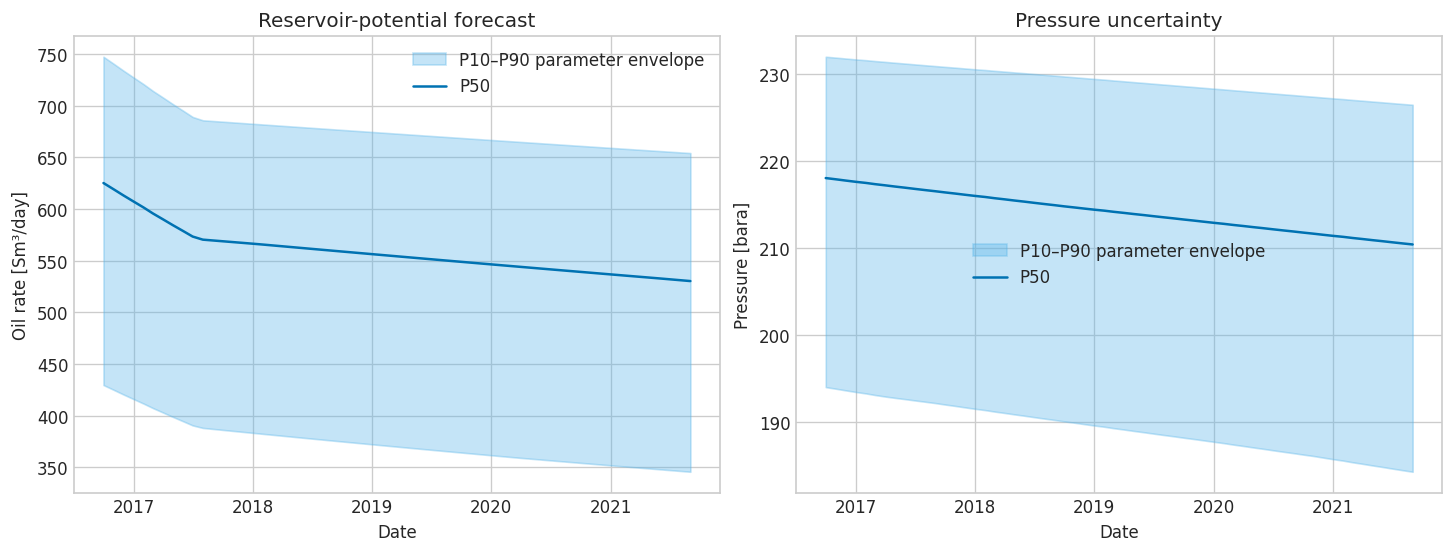

In [14]:
forecast_figure, forecast_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.5),
    constrained_layout=True,
)
for axis, column, ylabel, title in [
    (
        forecast_axes[0],
        "oil_rate_Sm3_day",
        "Oil rate [Sm³/day]",
        "Reservoir-potential forecast",
    ),
    (
        forecast_axes[1],
        "pressure_bara",
        "Pressure [bara]",
        "Pressure uncertainty",
    ),
]:
    pivot = forecast_quantiles.pivot(
        index="date",
        columns="quantile",
        values=column,
    )
    axis.fill_between(
        pivot.index,
        pivot[0.1],
        pivot[0.9],
        color="#56B4E9",
        alpha=0.35,
        label="P10–P90 parameter envelope",
    )
    axis.plot(
        pivot.index,
        pivot[0.5],
        color="#0072B2",
        label="P50",
    )
    axis.set(xlabel="Date", ylabel=ylabel, title=title)
    axis.legend()
plt.show()


## 7. Optional full OPM Flow acceptance path

The reduced simulator is always executed. If an installed Volve
deck and its complete include tree are available, set
`VOLVE_RUN_OPM_FLOW=1`, `VOLVE_ECLIPSE_DATA_PATH`, and optionally
`OPM_FLOW_EXECUTABLE`. The cell checks the binary, runs the selected
deck in a controlled directory, retains the return code and log
tail, and refuses to label reduced-model output as an OPM result.

A publication-grade OPM history match additionally requires summary
vector alignment, restart saturation closure, timestep and solver
diagnostics, well-control reconciliation, and independent review.


In [15]:
run_opm_flow = os.environ.get("VOLVE_RUN_OPM_FLOW") == "1"
opm_status = {
    "requested": run_opm_flow,
    "executed": False,
    "return_code": None,
    "deck": None,
    "log_tail": "not requested",
}
if run_opm_flow:
    if not source.measured_data_loaded:
        raise RuntimeError(
            "OPM acceptance requires the measured Marketplace source."
        )
    deck_relative_path = vc.select_asset(
        inventory,
        "reservoir-model",
        environment_name="VOLVE_ECLIPSE_DATA_PATH",
    )
    deck_path = vc.materialize_asset(
        source,
        inventory,
        deck_relative_path,
        work_dir / "opm_case",
    )
    flow_executable = os.environ.get("OPM_FLOW_EXECUTABLE")
    flow_executable = flow_executable or shutil.which("flow")
    if not flow_executable:
        raise RuntimeError("OPM Flow executable was not found.")
    opm_run = subprocess.run(
        [flow_executable, deck_path.name],
        cwd=deck_path.parent,
        capture_output=True,
        text=True,
        timeout=1800,
    )
    opm_status.update(
        {
            "executed": True,
            "return_code": opm_run.returncode,
            "deck": deck_relative_path,
            "log_tail": (
                opm_run.stdout[-2000:] + opm_run.stderr[-2000:]
            ),
        }
    )
    if opm_run.returncode != 0:
        raise RuntimeError(opm_status["log_tail"])
display(pd.DataFrame([opm_status]).drop(columns=["log_tail"]))
print(opm_status["log_tail"])


not requested


,requested,executed,return_code,deck
0,False,False,None,None


## 8. Per-well deliverability handoff

The gathering model needs every producing well, not only a field
total. Peak allocated oil share is used as a transparent first
estimate of relative productivity. The fitted field productivity,
terminal pressure, phase ratios, and ensemble forecast are written
with the exact data-status boundary for Notebook 7.


In [16]:
active_production = production.loc[
    production[rate_columns].sum(axis=1).gt(1.0)
].copy()
per_well_peak = (
    active_production.groupby("well", as_index=False)[
        "oil_rate_Sm3_day"
    ]
    .max()
    .rename(columns={"oil_rate_Sm3_day": "peak_oil_rate_Sm3_day"})
)
per_well_peak["productivity_factor"] = (
    per_well_peak["peak_oil_rate_Sm3_day"]
    / per_well_peak["peak_oil_rate_Sm3_day"].mean()
)
selected_case_index = int(field_history["oil_rate_Sm3_day"].idxmax())
selected_case_date = field_history.loc[selected_case_index, "date"]
selected_case_pressure_bara = float(
    matched_history.loc[selected_case_index, "pressure_bara"]
)
terminal_pressure_bara = float(
    matched_history["pressure_bara"].iloc[-1]
)
display(per_well_peak)
print(
    {
        "selected network date": selected_case_date,
        "selected network pressure bara": selected_case_pressure_bara,
        "terminal matched pressure bara": terminal_pressure_bara,
    }
)


{'selected network date': Timestamp('2010-01-01 00:00:00'), 'selected network pressure bara': 250.41192779349777, 'terminal matched pressure bara': 215.49879023258424}


,well,peak_oil_rate_Sm3_day,productivity_factor
0,15/9-F-1 C,1017.322967,1.267174
1,15/9-F-11 B,882.582049,1.099341
2,15/9-F-12,745.242163,0.928271
3,15/9-F-14,688.995864,0.858211
4,15/9-F-15 D,679.997252,0.847002


In [17]:
history_match_contract_path = vc.write_contract(
    work_dir / "06_reservoir_history_match.json",
    {
        "discipline": "reservoir-history-match",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "production_asset": production_relative_path,
        "production_provenance": production_provenance,
        "pressure_basis": pressure_basis,
        "neqsim": {
            "version": version("neqsim"),
            "source_ref": NEQSIM_SOURCE_REF,
            "resolved_commit": resolved_commit,
            "eos": "SRK",
            "mixing_rule": "classic",
            "bubble_pressure_bara": bubble_pressure_bara,
        },
        "simulator": "communicating two-tank finite-volume screen",
        "fitted_parameters": {
            name: float(value)
            for name, value in zip(PARAMETER_NAMES, fitted_parameters)
        },
        "calibration_metrics": calibration_metrics,
        "holdout_metrics": validation_metrics,
        "optimizer_success": bool(history_match.success),
        "jacobian_condition_number": effective_condition_number,
        "selected_network_date": selected_case_date.isoformat(),
        "selected_network_pressure_bara": selected_case_pressure_bara,
        "terminal_pressure_bara": terminal_pressure_bara,
        "per_well_deliverability": per_well_peak.to_dict("records"),
        "forecast_quantiles": [
            {
                **record,
                "date": record["date"].isoformat(),
            }
            for record in forecast_quantiles.to_dict("records")
        ],
        "opm_status": {
            key: value
            for key, value in opm_status.items()
            if key != "log_tail"
        },
        "limitations": [
            "reduced two-tank model unless OPM acceptance is executed",
            "teaching fluid assay unless measured PVT is selected",
            "parameter covariance is a local sensitivity approximation",
            "not a reserves classification or certified history match",
        ],
    },
    source,
)
print(history_match_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/06_reservoir_history_match.json


In [18]:
posterior_rms = float(np.sqrt(np.mean(posterior_residual**2)))
prior_rms = float(np.sqrt(np.mean(prior_residual**2)))
checks = {
    "production has multiple wells": production["well"].nunique() >= 2,
    "all phase rates are non-negative": bool(
        production[rate_columns].ge(0.0).all().all()
    ),
    "fluid composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "bubble pressure is physical": 20.0 < bubble_pressure_bara < 320.0,
    "optimizer converged": bool(history_match.success),
    "history match improves objective": posterior_rms < prior_rms,
    "fitted parameters remain bounded": bool(
        np.all(fitted_parameters >= LOWER_BOUNDS)
        and np.all(fitted_parameters <= UPPER_BOUNDS)
    ),
    "matched rates remain non-negative": bool(
        matched_history[rate_columns].ge(0.0).all().all()
    ),
    "matched water cut is physical": bool(
        matched_history["water_cut_fraction"].between(0.0, 1.0).all()
    ),
    "ensemble is complete": len(parameter_samples) == ensemble_size,
    "forecast quantiles are finite": bool(
        np.isfinite(
            forecast_quantiles
            .select_dtypes(include=[np.number])
            .to_numpy()
        ).all()
    ),
    "all producing wells exported": (
        len(per_well_peak) == active_production["well"].nunique()
    ),
    "handoff exists": history_match_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
failed_checks = validation.loc[~validation["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError(failed_checks)
print(f"All {len(checks)} reservoir-history-match checks passed.")


All 13 reservoir-history-match checks passed.


,check,passed
0,production has multiple wells,True
1,all phase rates are non-negative,True
2,fluid composition closes,True
3,bubble pressure is physical,True
4,optimizer converged,True
5,history match improves objective,True
6,fitted parameters remain bounded,True
7,matched rates remain non-negative,True
8,matched water cut is physical,True
9,ensemble is complete,True


## Results, limitations, and next notebook

This notebook executes a dynamic reservoir simulator, improves a
simultaneous pressure/oil/gas/water objective, tests a holdout
period, diagnoses non-uniqueness, and propagates fitted-parameter
uncertainty. A measured result is only produced when the
Marketplace workbook is selected and parsed successfully.

The two-tank model is suitable for transparent screening and for
testing data plumbing. Full subsurface decisions require the Volve
deck or a calibrated ensemble in OPM Flow, pressure and well-event
reconciliation, PVT and SCAL uncertainty, restart inspection, and
peer review. Notebook 7 uses the per-well handoff to solve tubing,
flowline, manifold, trunk, riser, and host backpressure together.


## Notebook validation evidence

Validation requires clean top-to-bottom execution with retained
tables, diagnostics, convergence evidence, four production-history
panels, four history-match panels, two sensitivity panels, and two
forecast panels. Every equation and visual must render correctly in
a Colab-compatible HTML/MathJax path.

Evidence level: independent PVT thermodynamics, conservation-style
state accounting, robust optimization, calibration/holdout split,
sensitivity cases, bounded uncertainty, and physical assertions.
This remains weaker than an authenticated OPM Flow history match to
the complete measured Volve dataset.
